# Explore here

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Carga con separador de punto y coma
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
df = pd.read_csv(url, sep=';')

print("Datos cargados correctamente.")
df.head()

Datos cargados correctamente.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [23]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [24]:
# Limpieza inicial para eliminar duplicados
df = df.drop_duplicates()

EDA 
Análisis Numérico y Correlación

/tmp/ipykernel_944/1738922884.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='viridis')


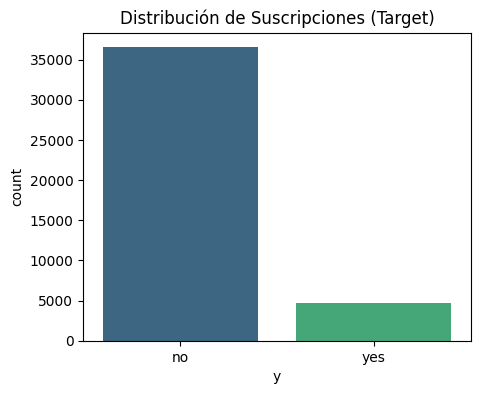

In [26]:
# 1) Balance de la variable objetivo
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribución de Suscripciones (Target)')
plt.show()



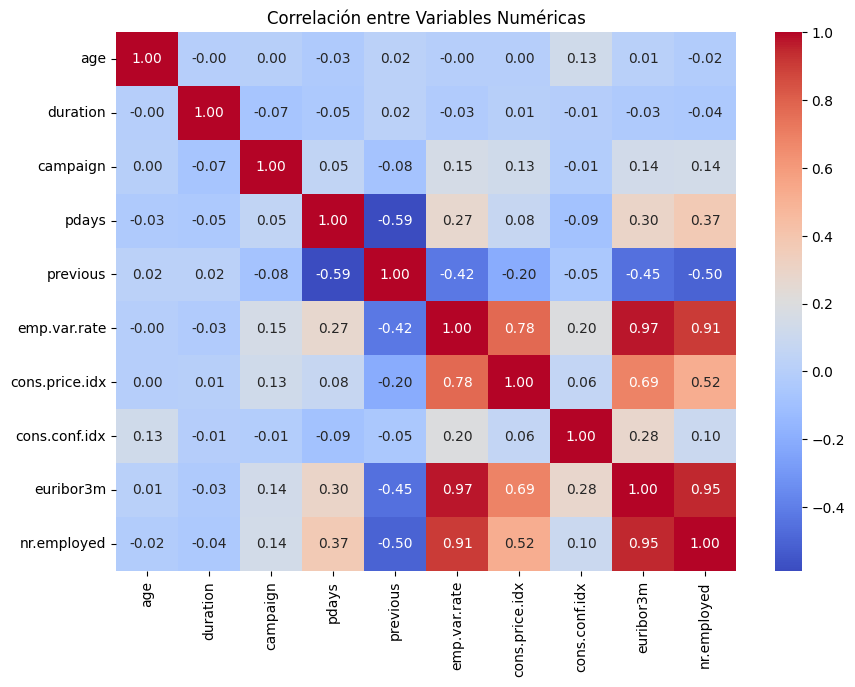

In [27]:
# 2) Matriz de correlación (Solo números)
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas')
plt.show()



Análisis: Matriz de Correlación 

- (Multicolinealidad)Identificación de Redundancias: Se observa una correlación extremadamente alta (> 0.90) entre las variables macroeconómicas: emp.var.rate, euribor3m y nr.employed.

- Independencia de Variables del Cliente: Variables como age y campaign muestran una correlación cercana a $0$ con las demás, lo que significa que aportan información única y valiosa al modelo sin interferencias.

- Acción Recomendada: Para optimizar el modelo, se sugiere eliminar dos de las tres variables macroeconómicas altamente correlacionadas (por ejemplo, mantener solo euribor3m) para simplificar el algoritmo y mejorar su robustez.

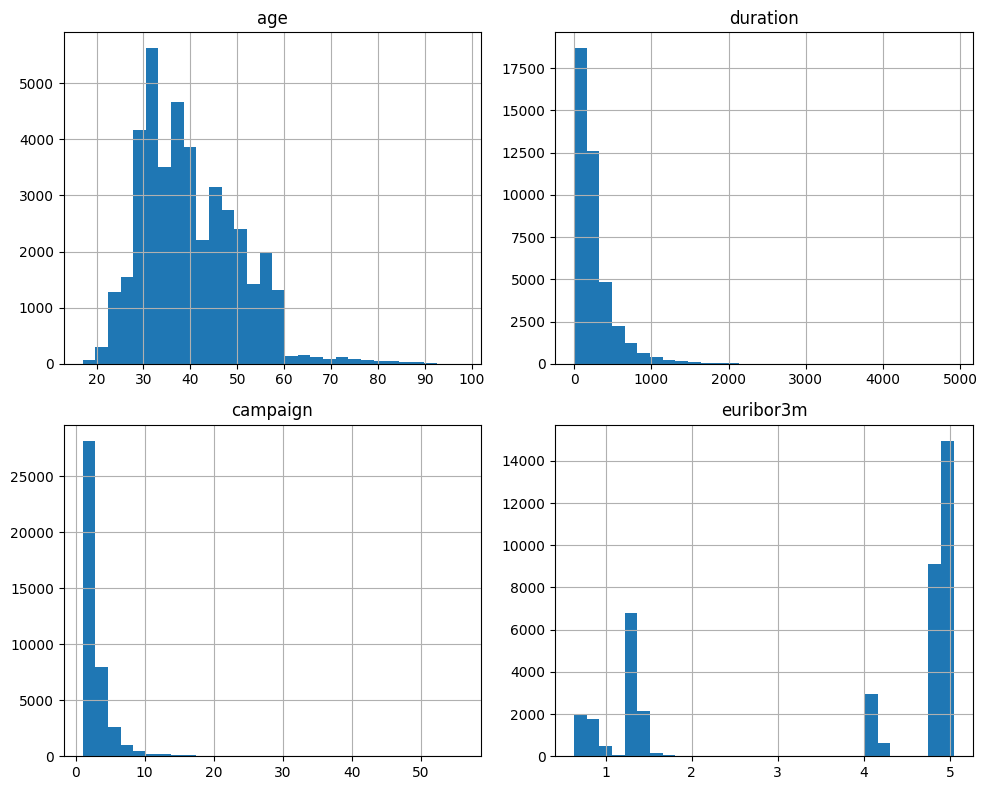

In [29]:
# 3) Histogramas de variables clave
df[['age', 'duration', 'campaign', 'euribor3m']].hist(bins=30, figsize=(10,8))
plt.tight_layout()
plt.show()

Análisis: Distribución de Variables Numéricas

Perfil de Edad: La mayoría de los clientes se concentran entre los 30 y 45 años, con una caída notable después de los 60 años. Esto indica que el público objetivo principal es la población en edad laboral activa.

Comportamiento de Campaña: La variable campaign muestra un sesgo a la derecha extremo; la gran mayoría de los clientes fueron contactados menos de 5 veces. 

Duración de Llamadas: La mayoría de las interacciones son breves, pero existen valores atípicos (outliers) de larga duración. (Es una "variable trampa" porque a mayor duración suele haber más éxito, pero no se conoce ese dato antes de realizar la llamada).

Indicadores Económicos (euribor3m): Se observa una distribución bimodal (dos picos claros). Esto sugiere que los datos fueron recolectados en dos periodos económicos muy distintos, uno con tasas bajas (cercanas al 1%) y otro con tasas altas (cercanas al 5%), lo cual influye directamente en la disposición del cliente a ahorrar.

EDA Análisis Categórico

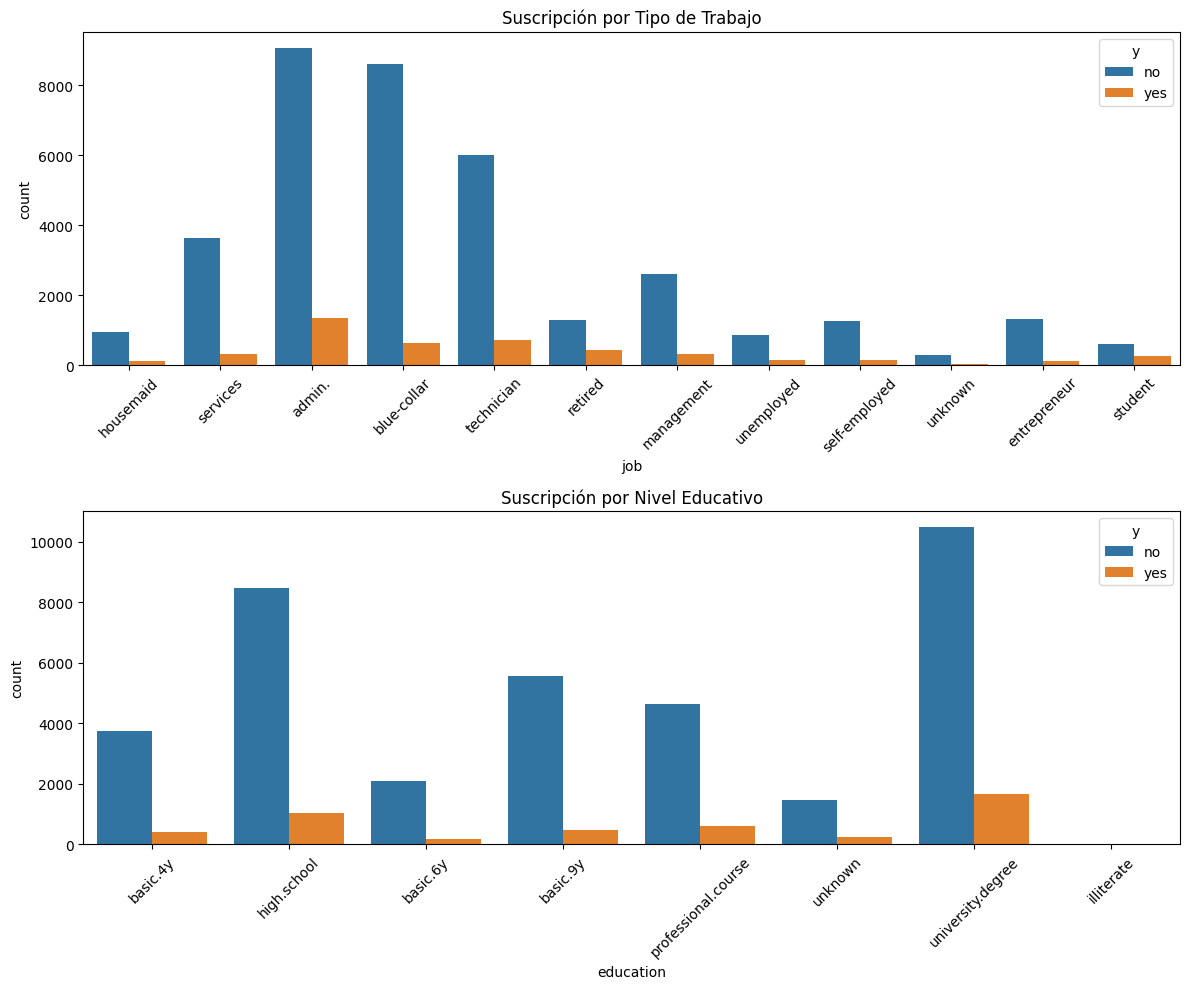

In [31]:
# Analizar cómo influye el trabajo y la educación en el "sí"
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

sns.countplot(data=df, x='job', hue='y', ax=axes[0])
axes[0].set_title('Suscripción por Tipo de Trabajo')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='education', hue='y', ax=axes[1])
axes[1].set_title('Suscripción por Nivel Educativo')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Análisis: Relación entre Variables Categóricas y Suscripción

- Segmentación por Trabajo (job): Se observa que los sectores de administración (admin.), técnicos y "blue-collar" son los más contactados.Sin embargo, las categorías de estudiantes y jubilados (retired) presentan una mayor tasa de conversión en comparación con los trabajadores activos. Esto sugiere que el banco tiene nichos de oportunidad en personas con diferentes disponibilidades de tiempo o perfiles de ahorro.

- Influencia del Nivel Educativo (education): Los clientes con título universitario (university degree) no solo son el grupo más numeroso, sino también el que más responde positivamente al producto. El nivel educativo parece ser un predictor directo de la apertura a productos financieros de largo plazo.

- Patrones de Éxito: Aunque el "No" predomina en todos los grupos (debido al desbalance general), estos gráficos permiten identificar qué perfiles tienen una "barra naranja" (sí) más alta.

In [32]:
# Convertir variables categóricas a dummies (0 y 1)
df_final = pd.get_dummies(df, drop_first=True)

# Separar X e y
# despues de utlizar get_dummies, la columna 'y' pasa a ser 'y_yes'
X = df_final.drop(['y_yes'], axis=1)
y = df_final['y_yes']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocesamiento completado.")

Preprocesamiento completado.


In [33]:
scaler = StandardScaler()

# Escalamos las X
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.")

Datos escalados correctamente.


Reporte
              precision    recall  f1-score   support

       False       0.98      0.85      0.91      7265
        True       0.44      0.87      0.59       971

    accuracy                           0.86      8236
   macro avg       0.71      0.86      0.75      8236
weighted avg       0.92      0.86      0.87      8236



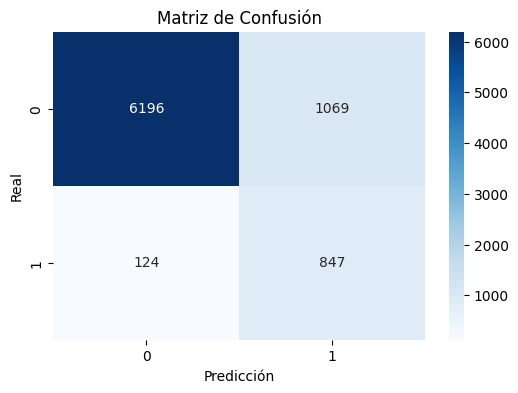

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, 

In [35]:
# Entrenar el modelo optimizado
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)

# Resultados
print("Reporte")
print(classification_report(y_test, y_pred))

# Matriz de Confusión Visual
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()